Epoch 1/10


c:\Users\user12\Anaconda3\envs\vivek\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9559 - loss: 0.1264 - val_accuracy: 0.9927 - val_loss: 0.0221
Epoch 2/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9929 - loss: 0.0215 - val_accuracy: 0.9945 - val_loss: 0.0156
Epoch 3/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9949 - loss: 0.0149 - val_accuracy: 0.9952 - val_loss: 0.0136
Epoch 4/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9962 - loss: 0.0122 - val_accuracy: 0.9950 - val_loss: 0.0145
Epoch 5/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9959 - loss: 0.0110 - val_accuracy: 0.9958 - val_loss: 0.0110
Epoch 6/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9962 - loss: 0.0101 - val_accuracy: 0.9965 - val_loss: 0.0104
Epoch 7/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9970 - loss: 0.0084 - val_accuracy: 0.9964 - val_loss: 0.0112
Epoch 8/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9970 - loss: 0.0075 - val_accurac

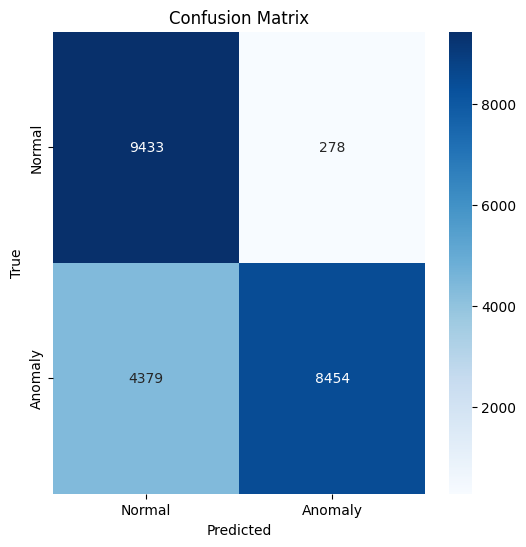

705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 510us/step


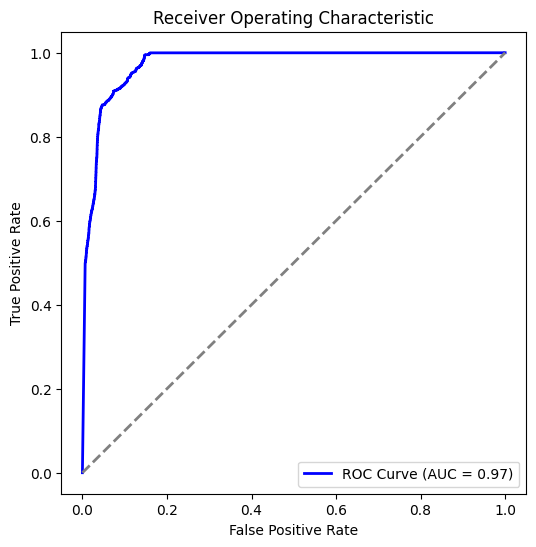

705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 756us/step
705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 683us/step


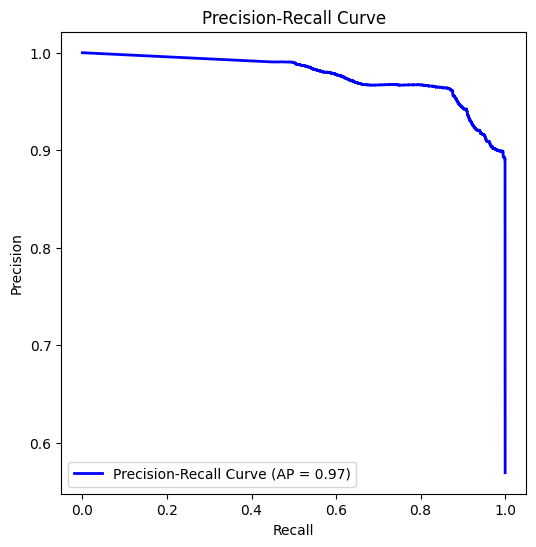

In [9]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Load NSL-KDD dataset
column_names = ["duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", "land", "wrong_fragment",
                "urgent", "hot", "num_failed_logins", "logged_in", "num_compromised", "root_shell", "su_attempted",
                "num_root", "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
                "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate",
                "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
                "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
                "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label", "drop"]
train_data = pd.read_csv("KDDTrain+.txt", header=None, names=column_names)
test_data = pd.read_csv("KDDTest+.txt", header=None, names=column_names)


# Preprocessing the dataset
def preprocess_data(data):
    # Encode categorical variables (protocol_type, service, and flag)
    label_encoder = LabelEncoder()

    # Apply LabelEncoder to the categorical columns
    data['protocol_type'] = label_encoder.fit_transform(data['protocol_type'])
    data['service'] = label_encoder.fit_transform(data['service'])
    data['flag'] = label_encoder.fit_transform(data['flag'])

    # Convert the label column to binary (0: normal, 1: attack)
    data['label'] = data['label'].apply(lambda x: 1 if x != 'normal' else 0)

    # Separate features and labels
    X = data.drop('label', axis=1).values
    y = data['label'].values

    # Normalize the feature values using StandardScaler
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    return X_scaled, y

# Preprocess training and test data
X_train, y_train = preprocess_data(train_data)
X_test, y_test = preprocess_data(test_data)

# Split the training data into train, validation, and test sets
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Reshape the data to fit RNN input shape (samples, time steps, features)
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_val = X_val.reshape(X_val.shape[0], 1, X_val.shape[1])
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

# Build the RNN model
model = Sequential()
model.add(SimpleRNN(64, input_shape=(X_train.shape[1], X_train.shape[2]), activation='relu'))
model.add(Dropout(0.2))  # To prevent overfitting
model.add(Dense(1, activation='sigmoid'))  # Binary classification

# Compile the model
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_val, y_val))

# Evaluate the model on the test set
y_pred = (model.predict(X_test) > 0.5).astype(int)

# Performance Metrics
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print metrics
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

# Plot Confusion Matrix
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap='Blues', xticklabels=["Normal", "Anomaly"], yticklabels=["Normal", "Anomaly"])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, model.predict(X_test))
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Precision-Recall Curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, model.predict(X_test))
average_precision = average_precision_score(y_test, model.predict(X_test))

plt.figure(figsize=(6, 6))
plt.plot(recall_vals, precision_vals, color='blue', lw=2, label=f"Precision-Recall Curve (AP = {average_precision:.2f})")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()
